# 02 — EDA y Pipeline de Limpieza

**Proyecto:** FinBalance — Predicción de Fragilidad Financiera  
**Dataset:** Encuesta de Demanda de Servicios Financieros 2022 (Banca de las Oportunidades)  
**Objetivo:** Limpiar, explorar y preparar el dataset para el entrenamiento del modelo.

---

### Contenido
1. Carga y diagnóstico inicial  
2. Limpieza de calidad (NS/NR, tipos, normalización)  
3. Análisis Exploratorio (EDA)  
4. Imputación por estrategia  
5. Codificación y preparación para modelado  
6. Guardado del dataset procesado

---
## 0 — Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Paleta de colores del proyecto
AZUL  = '#1F4E79'
TEAL  = '#1D9E75'
CORAL = '#D95A30'
AMBER = '#BA7517'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

RUTA_RAW       = Path('../data/raw/Encuesta_demanda_2022_microdatos.xlsx')
RUTA_PROCESSED = Path('../data/processed')
RUTA_PROCESSED.mkdir(parents=True, exist_ok=True)

COLS_BIN = [
    'prod_cuenta_ahorro','prod_tarjeta_debito','prod_monedero',
    'prod_cdt','prod_fondo_inv','prod_fondo_emp',
    'ing_salario','ing_pension','ing_arriendos','ing_honorarios',
    'ing_ventas','ing_subsidios','ing_remesas','ing_ayuda_familiar',
    'gasto_arriendo','gasto_servicios','gasto_seg_social',
    'hab_encargado_gastos','hab_encargado_presup','hab_usa_app_bancaria',
    'comp_tiene_plan',
]

print('Configuración lista.')

Configuración lista.


---
## 1 — Carga y diagnóstico inicial

In [2]:
cols_needed = [
    'P407',
    'T401_3','T401_4','T401_8','T405_2','T405_3','T405_8',
    'T402_3','T406_2','P406A','T405_4',
    'EDAD','GENERO','P704','P705','P708','ESTRATO','RURALIDAD',
    'T208_1','T208_2','T208_3','T208_5','T208_6','T208_8','T208_9',
    'T208_10','P714','P716','P715','T211_1','T211_2','T211_5',
    'T101_1','T101_2','T101_5','T101_6','T101_7','T101_8','P103','P104',
    'P301','T406_1','T406_3','T406_4',
]

df = pd.read_excel(RUTA_RAW, usecols=lambda c: c in cols_needed + ['REGIÓN'])
if 'REGIÓN' in df.columns:
    df = df.rename(columns={'REGIÓN': 'REGION'})

df = df.rename(columns={
    'P407'  : 'fragilidad_financiera',
    'T401_3': 'perc_nunca_tendre',  'T401_4': 'perc_disfruta_vida',
    'T401_8': 'perc_confianza_dec',
    'T405_2': 'perc_camino_obj',    'T405_3': 'perc_deuda_manejable',
    'T405_8': 'perc_control_sit',   'T405_4': 'comp_deuda_mayor_activos',
    'T402_3': 'comp_atraso_pagos',  'T406_2': 'comp_tiene_plan',
    'P406A' : 'comp_frec_cumple_plan',
    'EDAD'  : 'edad',     'GENERO'   : 'genero',
    'P704'  : 'ocupacion','P705'     : 'tipo_vinculacion',
    'P708'  : 'nivel_educativo',    'ESTRATO'  : 'estrato',
    'REGION': 'region',  'RURALIDAD' : 'ruralidad',
    'T208_1': 'ing_salario',   'T208_2': 'ing_pension',
    'T208_3': 'ing_arriendos', 'T208_5': 'ing_honorarios',
    'T208_6': 'ing_ventas',    'T208_8': 'ing_subsidios',
    'T208_9': 'ing_remesas',   'T208_10':'ing_ayuda_familiar',
    'P714'  : 'rango_ingresos','P716'  : 'frec_ingresos',
    'P715'  : 'rango_gastos',
    'T211_1': 'gasto_arriendo','T211_2': 'gasto_servicios',
    'T211_5': 'gasto_seg_social',
    'T101_1': 'prod_cuenta_ahorro', 'T101_2': 'prod_tarjeta_debito',
    'T101_5': 'prod_monedero',      'T101_6': 'prod_cdt',
    'T101_7': 'prod_fondo_inv',     'T101_8': 'prod_fondo_emp',
    'P103'  : 'beneficiario_subsidio','P104': 'prod_mas_usado',
    'P301'  : 'solicito_credito',
    'T406_1': 'hab_encargado_gastos','T406_3':'hab_encargado_presup',
    'T406_4': 'hab_usa_app_bancaria',
})

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 5,610 filas x 45 columnas


In [3]:
print(f'Shape: {df.shape}')
print()
print('Tipos de datos:')
print(df.dtypes.value_counts())
print()
df.head(3)

Shape: (5610, 45)

Tipos de datos:
object    44
int64      1
Name: count, dtype: int64



,prod_cuenta_ahorro,prod_tarjeta_debito,prod_monedero,prod_cdt,prod_fondo_inv,prod_fondo_emp,beneficiario_subsidio,prod_mas_usado,ing_salario,ing_pension,...,edad,ocupacion,tipo_vinculacion,nivel_educativo,estrato,rango_ingresos,rango_gastos,frec_ingresos,region,ruralidad
0,NO,NO,NO,NO,NO,NO,NaN,NaN,No,No,...,35,Oficios del hogar,NaN,Secundaria,1,Entre 500.001 y 750.000,Entre 1.000.001 y 1.500.000,Irregularmente,Eje cafetero,Ciudades y aglomerac
1,NO,NO,SÍ,NO,NO,NO,"Sí, y recibe el dinero a través de una tarjeta...","Monederos digitales (ej.Daviplata, ahorro a la...",No,No,...,48,Oficios del hogar,NaN,Primaria,1,Entre 750.001 y 1.000.000,Entre 250.001 y 500.000,Irregularmente,Eje cafetero,Ciudades y aglomerac
2,NO,SÍ,NO,NO,NO,NO,No,Tarjeta de débito,No,Sí,...,69,Oficios del hogar,NaN,Primaria,1,Entre 500.001 y 750.000,Entre 500.001 y 750.000,Mensual,Eje cafetero,Ciudades y aglomerac


In [4]:
# Diagnóstico de nulos
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
resumen_nulos = (pd.DataFrame({'nulos': nulos, 'pct_%': pct})
                 .query('nulos > 0')
                 .sort_values('pct_%', ascending=False))
print(f'Variables con nulos reales: {len(resumen_nulos)} / {len(df.columns)}')
print(f'Total nulos: {nulos.sum():,}\n')
print(resumen_nulos.to_string())

Variables con nulos reales: 4 / 45
Total nulos: 9,706

                       nulos  pct_%
tipo_vinculacion        2804   50.0
prod_mas_usado          2342   41.7
beneficiario_subsidio   2329   41.5
comp_frec_cumple_plan   2231   39.8


In [5]:
# Duplicados
dup = df.duplicated().sum()
print(f'Registros duplicados exactos: {dup}')
if dup > 0:
    df = df.drop_duplicates(keep='first')
    print(f'  Eliminados. Filas restantes: {len(df):,}')
else:
    print('  Sin duplicados — OK')

Registros duplicados exactos: 0
  Sin duplicados — OK


---
## 2 — Limpieza de calidad de datos

El dataset es una encuesta institucional con 6 formatos distintos de NS/NR
(no-respuesta). Ninguno es `NaN` real — deben convertirse antes de cualquier análisis.

| Problema | Técnica |
|---|---|
| NS/NR en 6 formatos (texto plano, con HTML, con código) | Detección por patrón → `NaN` |
| Escalas `T405_x` (1–5) guardadas como `str` | `pd.to_numeric()` |
| `'SÍ'`/`'NO'` (mayúsculas en T101_x) vs `'Sí'`/`'No'` | Normalización binaria |
| `estrato` con texto mezclado | Limpieza → numérico |

In [6]:
# 2.1 NS/NR → NaN  (6 formatos de encuesta, incluyendo tags HTML)
def es_nsnr(v):
    if pd.isnull(v): return False
    s = re.sub(r'<[^>]+>', '', str(v)).strip()
    return s in [
        'NS/NR (E: No lea esta opción)', 'NS/NR (E: No leer)',
        '9 (NS/NR)', 'NS/NR', 'No tiene',
    ]

nulos_antes = df.isnull().sum().sum()
for col in df.columns:
    mask = df[col].apply(es_nsnr)
    if mask.sum() > 0:
        df.loc[mask, col] = np.nan
        print(f'  [{col}] {mask.sum()} NS/NR → NaN')

print(f'\nNS/NR convertidos : {df.isnull().sum().sum() - nulos_antes:,}')
print(f'Total nulos ahora  : {df.isnull().sum().sum():,}')

  [prod_cuenta_ahorro] 4 NS/NR → NaN
  [prod_tarjeta_debito] 3 NS/NR → NaN
  [prod_monedero] 4 NS/NR → NaN
  [prod_cdt] 29 NS/NR → NaN
  [prod_fondo_inv] 17 NS/NR → NaN
  [prod_fondo_emp] 13 NS/NR → NaN
  [ing_salario] 7 NS/NR → NaN
  [ing_arriendos] 1 NS/NR → NaN
  [ing_honorarios] 6 NS/NR → NaN
  [ing_ventas] 5 NS/NR → NaN
  [ing_subsidios] 6 NS/NR → NaN
  [ing_remesas] 3 NS/NR → NaN
  [ing_ayuda_familiar] 11 NS/NR → NaN
  [solicito_credito] 78 NS/NR → NaN
  [perc_camino_obj] 108 NS/NR → NaN
  [perc_deuda_manejable] 106 NS/NR → NaN
  [comp_deuda_mayor_activos] 115 NS/NR → NaN
  [perc_control_sit] 101 NS/NR → NaN
  [hab_encargado_gastos] 20 NS/NR → NaN
  [comp_tiene_plan] 9 NS/NR → NaN
  [hab_encargado_presup] 13 NS/NR → NaN
  [hab_usa_app_bancaria] 14 NS/NR → NaN
  [comp_frec_cumple_plan] 50 NS/NR → NaN
  [fragilidad_financiera] 383 NS/NR → NaN
  [nivel_educativo] 6 NS/NR → NaN
  [estrato] 286 NS/NR → NaN
  [rango_ingresos] 241 NS/NR → NaN
  [rango_gastos] 194 NS/NR → NaN
  [frec_ing

In [7]:
# 2.2 Escalas ordinales T405_x: string '1'..'5' → numérico
# (el '9 (NS/NR)' ya fue convertido a NaN en el paso anterior)
cols_escala = ['perc_camino_obj','perc_deuda_manejable',
               'perc_control_sit','comp_deuda_mayor_activos']
for col in cols_escala:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    unicos = sorted(df[col].dropna().unique().astype(int))
    print(f'[{col}] valores: {unicos} | NaN: {df[col].isnull().sum()}')

[perc_camino_obj] valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] | NaN: 108
[perc_deuda_manejable] valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] | NaN: 106
[perc_control_sit] valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] | NaN: 101
[comp_deuda_mayor_activos] valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] | NaN: 115


In [8]:
# 2.3 Normalizar respuestas binarias: 'SÍ'/'NO' (T101_x) → 'Sí'/'No'
def norm_binaria(v):
    if pd.isnull(v): return np.nan
    s = str(v).strip()
    if s in ('SÍ', 'Sí', 'SI'): return 'Sí'
    if s in ('NO', 'No'):        return 'No'
    return np.nan

for col in COLS_BIN:
    df[col] = df[col].apply(norm_binaria)

print('Normalización binaria completada.')
print('Ejemplo — prod_cuenta_ahorro:')
print(df['prod_cuenta_ahorro'].value_counts(dropna=False))

Normalización binaria completada.
Ejemplo — prod_cuenta_ahorro:
prod_cuenta_ahorro
No     3608
Sí     1998
NaN       4
Name: count, dtype: int64


In [9]:
# 2.4 Estrato → numérico (los 'NS/NR' y 'No tiene' ya son NaN)
df['estrato'] = pd.to_numeric(df['estrato'], errors='coerce')
print('estrato → numérico:')
print(df['estrato'].value_counts(dropna=False).sort_index())

estrato → numérico:
estrato
1.0    1979
2.0    2052
3.0    1027
4.0     169
5.0      61
6.0      36
NaN     286
Name: count, dtype: int64


In [10]:
# Resumen post-limpieza
nulos_post = df.isnull().sum()
pct_post   = (nulos_post / len(df) * 100).round(1)
resumen_post = (pd.DataFrame({'nulos': nulos_post, 'pct_%': pct_post})
                .query('nulos > 0').sort_values('pct_%', ascending=False))
print('Nulos tras limpieza:')
print(resumen_post.to_string())
print(f'\nTotal filas: {len(df):,} | Variables con nulos: {len(resumen_post)}')

Nulos tras limpieza:
                          nulos  pct_%
tipo_vinculacion           2804   50.0
prod_mas_usado             2342   41.7
beneficiario_subsidio      2329   41.5
comp_frec_cumple_plan      2281   40.7
frec_ingresos               399    7.1
fragilidad_financiera       383    6.8
estrato                     286    5.1
rango_ingresos              241    4.3
rango_gastos                194    3.5
comp_deuda_mayor_activos    115    2.0
perc_deuda_manejable        106    1.9
perc_camino_obj             108    1.9
perc_control_sit            101    1.8
solicito_credito             78    1.4
prod_cdt                     29    0.5
hab_encargado_gastos         20    0.4
prod_fondo_inv               17    0.3
hab_usa_app_bancaria         14    0.2
prod_fondo_emp               13    0.2
ing_ayuda_familiar           11    0.2
comp_tiene_plan               9    0.2
hab_encargado_presup         13    0.2
prod_monedero                 4    0.1
prod_tarjeta_debito           3    0.1
ing_

---
## 3 — Análisis Exploratorio (EDA)

Cuatro visualizaciones clave para entender la distribución del problema
antes de entrenar el modelo.

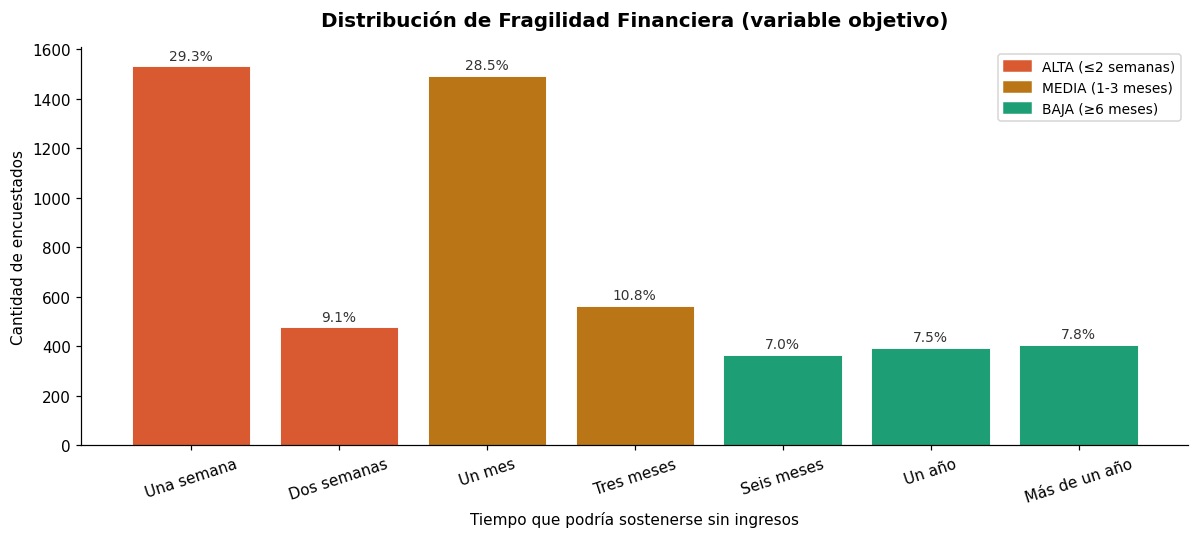

NS/NR excluidos del gráfico: 383


In [11]:
# 3.1 Distribución de la variable objetivo
orden = ['Una semana','Dos semanas','Un mes','Tres meses',
         'Seis meses','Un año','Más de un año']
conteo = df['fragilidad_financiera'].value_counts()
conteo = conteo.reindex([x for x in orden if x in conteo.index])
colores_barra = [CORAL]*2 + [AMBER]*2 + [TEAL]*3

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(conteo.index, conteo.values, color=colores_barra, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, conteo.values):
    pct = val / conteo.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color='#333')
ax.set_title('Distribución de Fragilidad Financiera (variable objetivo)', pad=14)
ax.set_xlabel('Tiempo que podría sostenerse sin ingresos')
ax.set_ylabel('Cantidad de encuestados')
ax.tick_params(axis='x', rotation=18)
leyenda = [mpatches.Patch(color=CORAL, label='ALTA (≤2 semanas)'),
           mpatches.Patch(color=AMBER, label='MEDIA (1-3 meses)'),
           mpatches.Patch(color=TEAL,  label='BAJA (≥6 meses)')]
ax.legend(handles=leyenda, fontsize=9)
plt.tight_layout()
plt.savefig('../docs/viz_01_fragilidad_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'NS/NR excluidos del gráfico: {df["fragilidad_financiera"].isnull().sum()}')

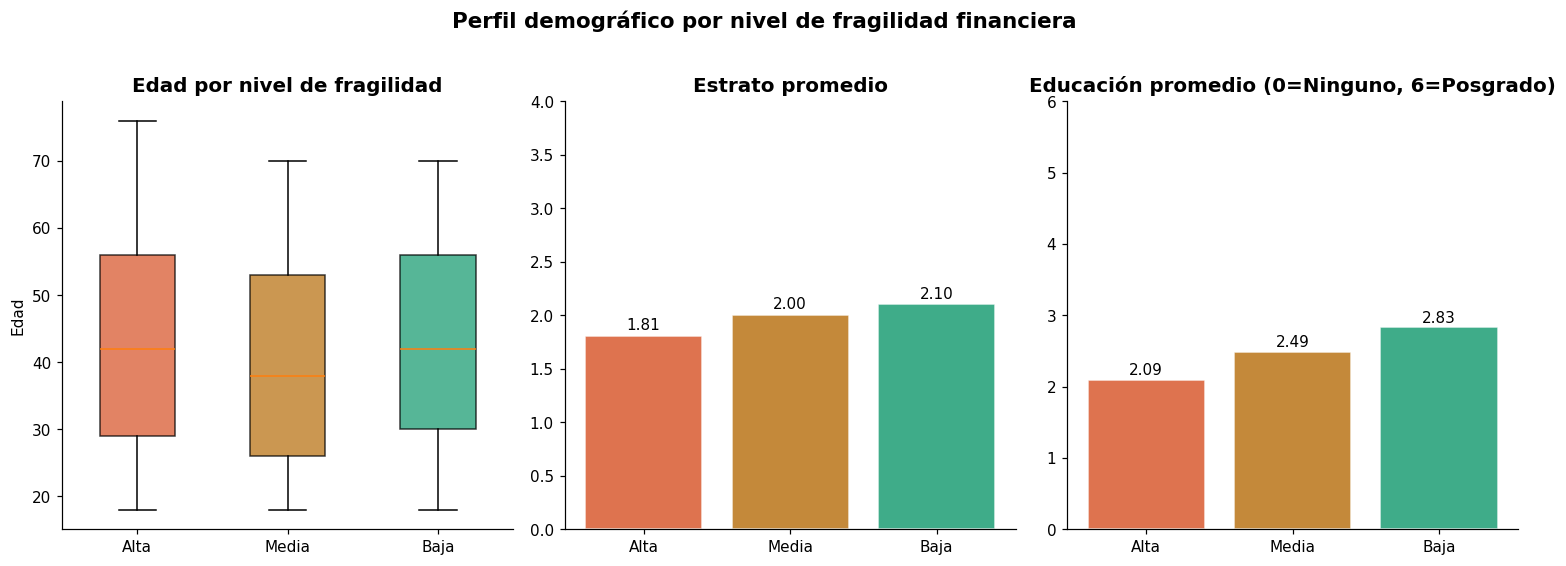

In [12]:
# 3.2 Perfil demográfico por nivel de fragilidad
mapa_nivel = {'Una semana':'Alta','Dos semanas':'Alta',
              'Un mes':'Media','Tres meses':'Media',
              'Seis meses':'Baja','Un año':'Baja','Más de un año':'Baja'}
df['nivel_fragilidad'] = df['fragilidad_financiera'].map(mapa_nivel)
orden_niv = ['Alta','Media','Baja']
col_niv   = [CORAL, AMBER, TEAL]
dv = df.dropna(subset=['nivel_fragilidad'])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Boxplot edad
datos_edad = [dv[dv['nivel_fragilidad']==n]['edad'].dropna().values for n in orden_niv]
bp = axes[0].boxplot(datos_edad, patch_artist=True, labels=orden_niv, widths=0.5)
for patch, c in zip(bp['boxes'], col_niv):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0].set_title('Edad por nivel de fragilidad'); axes[0].set_ylabel('Edad')

# Estrato promedio
est_niv = dv.groupby('nivel_fragilidad')['estrato'].mean().reindex(orden_niv)
axes[1].bar(orden_niv, est_niv.values, color=col_niv, alpha=0.85, edgecolor='white')
for i, val in enumerate(est_niv.values):
    axes[1].text(i, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Estrato promedio'); axes[1].set_ylim(0, 4)

# Nivel educativo promedio
mapa_edu_viz = {'Ninguno':0,'Primaria':1,'Secundaria':2,
                'Técnico':3,'Tecnólogos':4,'Universitarios':5,'Posgrado':6}
dv2 = dv.copy()
dv2['edu_num'] = dv2['nivel_educativo'].map(mapa_edu_viz)
edu_niv = dv2.groupby('nivel_fragilidad')['edu_num'].mean().reindex(orden_niv)
axes[2].bar(orden_niv, edu_niv.values, color=col_niv, alpha=0.85, edgecolor='white')
for i, val in enumerate(edu_niv.values):
    axes[2].text(i, val + 0.03, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[2].set_title('Educación promedio (0=Ninguno, 6=Posgrado)')
axes[2].set_ylim(0, 6)

plt.suptitle('Perfil demográfico por nivel de fragilidad financiera',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/viz_02_perfil_demografico.png', dpi=120, bbox_inches='tight')
plt.show()

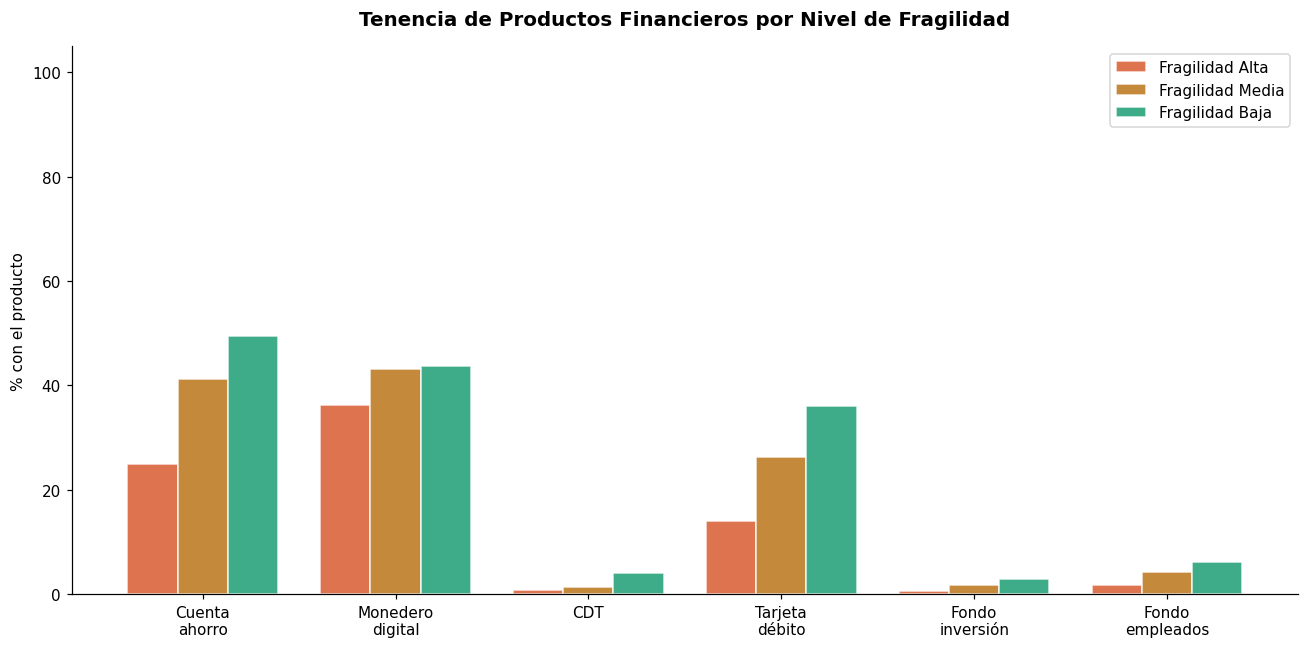

In [13]:
# 3.3 Tenencia de productos financieros por nivel de fragilidad
prods   = ['prod_cuenta_ahorro','prod_monedero','prod_cdt',
           'prod_tarjeta_debito','prod_fondo_inv','prod_fondo_emp']
nombres = ['Cuenta\nahorro','Monedero\ndigital','CDT',
           'Tarjeta\ndébito','Fondo\ninversión','Fondo\nempleados']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(prods)); width = 0.26
for i, (nivel, color) in enumerate(zip(orden_niv, col_niv)):
    sub  = dv[dv['nivel_fragilidad'] == nivel]
    pcts = [(sub[c] == 'Sí').sum() / len(sub) * 100 for c in prods]
    ax.bar(x + i*width, pcts, width, label=f'Fragilidad {nivel}',
           color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(nombres, ha='center')
ax.set_ylabel('% con el producto')
ax.set_title('Tenencia de Productos Financieros por Nivel de Fragilidad', pad=14)
ax.legend(); ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('../docs/viz_03_productos_financieros.png', dpi=120, bbox_inches='tight')
plt.show()

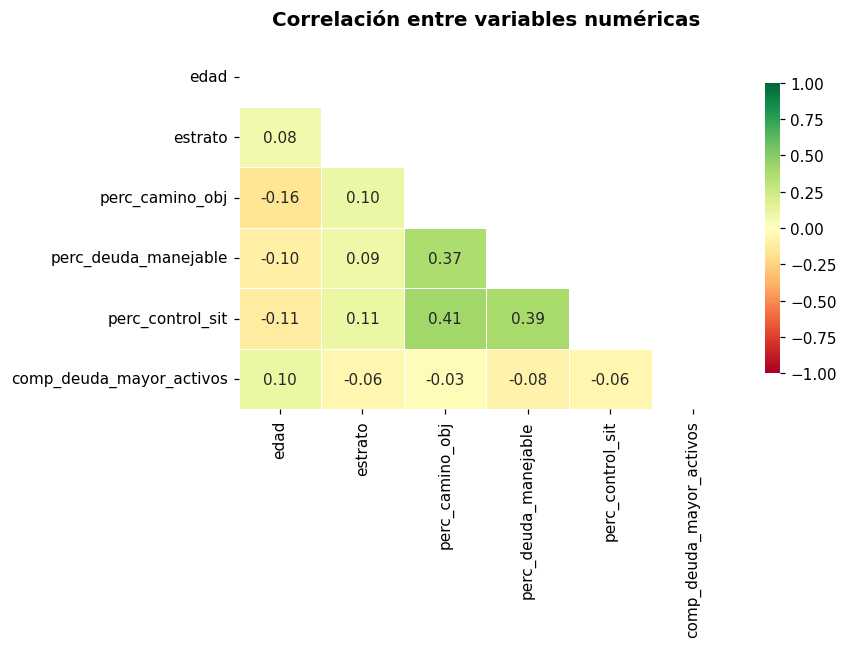

In [14]:
# 3.4 Correlación entre variables numéricas
cols_num = ['edad','estrato','perc_camino_obj','perc_deuda_manejable',
            'perc_control_sit','comp_deuda_mayor_activos']
corr = df[cols_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre variables numéricas', pad=14)
plt.tight_layout()
plt.savefig('../docs/viz_04_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4 — Imputación por estrategia estadística

Los nulos restantes son **condicionales por diseño de la encuesta**
(no datos faltantes aleatorios), por lo que la imputación refleja la lógica de negocio.

| Columna | Razón del nulo | Valor imputado |
|---|---|---|
| `tipo_vinculacion` | No aplica a quienes no trabajan | `'No aplica'` |
| `beneficiario_subsidio` | Pregunta condicional | `'No'` |
| `prod_mas_usado` | Sin productos financieros | `'No informa'` |
| `comp_frec_cumple_plan` | Sin plan financiero | `'No tiene plan'` |
| Escalas `T405_x` con NS/NR residual | No-respuesta en escala | Mediana (valor central) |

In [15]:
imputaciones = {
    'tipo_vinculacion'       : 'No aplica',
    'beneficiario_subsidio'  : 'No',
    'prod_mas_usado'         : 'No informa',
    'comp_frec_cumple_plan'  : 'No tiene plan',
}
for col, valor in imputaciones.items():
    n = df[col].isnull().sum()
    df[col] = df[col].fillna(valor)
    print(f'[{col}] {n:,} nulos → "{valor}"')

# Escalas ordinales: mediana (valor central de la escala 1-5)
cols_escala = ['perc_camino_obj','perc_deuda_manejable',
               'perc_control_sit','comp_deuda_mayor_activos']
for col in cols_escala:
    n = df[col].isnull().sum()
    if n > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'[{col}] {n} nulos → mediana ({med:.0f})')

print(f'\nNulos restantes en df: {df.isnull().sum().sum()}')

[tipo_vinculacion] 2,804 nulos → "No aplica"
[beneficiario_subsidio] 2,329 nulos → "No"
[prod_mas_usado] 2,342 nulos → "No informa"
[comp_frec_cumple_plan] 2,281 nulos → "No tiene plan"
[perc_camino_obj] 108 nulos → mediana (3)
[perc_deuda_manejable] 106 nulos → mediana (4)
[perc_control_sit] 101 nulos → mediana (4)
[comp_deuda_mayor_activos] 115 nulos → mediana (1)

Nulos restantes en df: 2135


---
## 5 — Codificación y preparación para modelado

Se separa `df_model` (sin NS/NR en la variable objetivo), se codifican las variables
y se divide en **train / validación / test** con semilla fija.

### ¿Por qué se eliminan algunas columnas?

Después de aplicar OHE y mapeos ordinales, quedan columnas con texto libre
que sklearn no puede procesar como números:

| Columna eliminada | Razón |
|---|---|
| `tipo_vinculacion` | Ya imputado como `'No aplica'` — la info quedó capturada |
| `solicito_credito` | Texto descriptivo largo, OHE generaría columnas muy dispersas |
| `comp_frec_cumple_plan` | Ya imputado como `'No tiene plan'` |
| `prod_mas_usado`, `ocupacion` | Alta cardinalidad sin orden definido |
| `perc_nunca_tendre`, etc. | Escalas de percepción con NS/NR altos — baja calidad |

> **Nota anti-fuga de datos:** el escalado (`StandardScaler`) se ajustará
> **solo** sobre el conjunto de entrenamiento en `03_modelado.ipynb`.

### Nota sobre escalamiento

El escalamiento (`StandardScaler`, `MinMaxScaler`) **no se aplica en esta etapa**.
En el EDA aun no se ha definido que algoritmo se usara, y el escalamiento es una decision
que depende del modelo: los arboles de decision (Random Forest, Gradient Boosting)
son invariantes a la escala, mientras que los modelos lineales (Regresion Logistica)
y basados en distancias (KNN) si lo requieren.
Aplicarlo aqui, antes de conocer el modelo final, seria una decision prematura.
El escalamiento se delega al `Pipeline` de `03_modelado.ipynb`, donde se ajusta
**unicamente sobre el conjunto de entrenamiento** para evitar fuga de datos.

In [16]:
# 5.1 Variable objetivo → etiqueta numérica ordinal
mapa_fragilidad = {
    'Una semana': 3, 'Dos semanas': 3,   # ALTA
    'Un mes'    : 2, 'Tres meses' : 2,   # MEDIA
    'Seis meses': 1, 'Un año'     : 1,   # BAJA
    'Más de un año': 1,
}
df['fragilidad_label'] = df['fragilidad_financiera'].map(mapa_fragilidad)
df_model = df.dropna(subset=['fragilidad_label']).copy()

print(f'Registros totales        : {len(df):,}')
print(f'Registros para modelar   : {len(df_model):,}')
print(f'Descartados (NS/NR obj.) : {len(df) - len(df_model):,}')
print()
print('Distribución de clases:')
etiquetas = {1:'Baja  (≥6 meses)', 2:'Media (1-3 meses)', 3:'Alta  (≤2 semanas)'}
for k, v in df_model['fragilidad_label'].value_counts().sort_index().items():
    print(f'  Clase {int(k)} — {etiquetas[k]}: {v:,} ({v/len(df_model)*100:.1f}%)')

Registros totales        : 5,610
Registros para modelar   : 5,227
Descartados (NS/NR obj.) : 383

Distribución de clases:
  Clase 1 — Baja  (≥6 meses): 1,165 (22.3%)
  Clase 2 — Media (1-3 meses): 2,056 (39.3%)
  Clase 3 — Alta  (≤2 semanas): 2,006 (38.4%)


In [17]:
# 5.2 Codificación de features

# Binarias: Sí=1, No=0
for col in COLS_BIN:
    df_model[col] = df_model[col].map({'Sí': 1, 'No': 0})

# Ordinales con orden definido
mapa_edu = {'Ninguno':0,'Primaria':1,'Secundaria':2,
            'Técnico':3,'Tecnólogos':4,'Universitarios':5,'Posgrado':6}
df_model['nivel_educativo'] = df_model['nivel_educativo'].map(mapa_edu)

mapa_atraso = {'Nunca':1,'Casi nunca':2,'A veces':3,'Casi siempre':4,'Siempre':5}
df_model['comp_atraso_pagos'] = df_model['comp_atraso_pagos'].map(mapa_atraso)

mapa_ingresos = {
    'Menos de 250.000':1,'Entre 250.001 y 500.000':2,
    'Entre 500.001 y 750.000':3,'Entre 750.001 y 1.000.000':4,
    'Entre 1.000.001 y 1.500.000':5,'Entre 1.500.001 y 2.000.000':6,
    'Entre 2.000.001 y 3.000.000':7,'Entre 3.000.001 y 4.000.000':8,
    'Entre 4.000.001 y 5.000.000':9,'Más de 5.000.000':10,
}
df_model['rango_ingresos'] = df_model['rango_ingresos'].map(mapa_ingresos)
df_model['rango_gastos']   = df_model['rango_gastos'].map(mapa_ingresos)

# Nominales: One-Hot Encoding = convertir variables categóricas (texto/etiquetas sin orden matemático) en un formato de números binarios (0 y 1) que los algoritmos matemáticos puedan entender.
cols_ohe = ['genero','ruralidad','region']
df_model = pd.get_dummies(df_model, columns=cols_ohe, drop_first=True, dtype=int)

# Eliminar columnas de texto no codificadas: los algoritmos de sklearn operan en espacio vectorial numérico - Un string 'Empleado(a) u obrero(a)' no tiene representación matemática directa — no puedes sumar ni comparar strings con esos operadores.
cols_drop = ['fragilidad_financiera','nivel_fragilidad','tipo_vinculacion',
             'prod_mas_usado','beneficiario_subsidio','solicito_credito',
             'comp_frec_cumple_plan','ocupacion','frec_ingresos',
             'perc_nunca_tendre','perc_disfruta_vida','perc_confianza_dec']
df_model.drop(columns=[c for c in cols_drop if c in df_model.columns], inplace=True)

print(f'Dataset para modelar: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas')
print(f'\nFeatures ({df_model.shape[1]-1}):')
print([c for c in df_model.columns if c != 'fragilidad_label'])

Dataset para modelar: 5,227 filas x 41 columnas

Features (40):
['prod_cuenta_ahorro', 'prod_tarjeta_debito', 'prod_monedero', 'prod_cdt', 'prod_fondo_inv', 'prod_fondo_emp', 'ing_salario', 'ing_pension', 'ing_arriendos', 'ing_honorarios', 'ing_ventas', 'ing_subsidios', 'ing_remesas', 'ing_ayuda_familiar', 'gasto_arriendo', 'gasto_servicios', 'gasto_seg_social', 'comp_atraso_pagos', 'perc_camino_obj', 'perc_deuda_manejable', 'comp_deuda_mayor_activos', 'perc_control_sit', 'hab_encargado_gastos', 'comp_tiene_plan', 'hab_encargado_presup', 'hab_usa_app_bancaria', 'edad', 'nivel_educativo', 'estrato', 'rango_ingresos', 'rango_gastos', 'genero_Masculino', 'ruralidad_Intermedio', 'ruralidad_Rural', 'ruralidad_Rural disperso', 'region_Centro Oriente', 'region_Centro Sur', 'region_Eje cafetero', 'region_Llano', 'region_Pacífico']


In [18]:
# 5.3 Separación train / validación / test
# Proporciones: 70% train | 15% validación | 15% test
# Semilla fija (random_state=42) → resultados reproducibles
# stratify=y → mantiene la distribución de clases en los tres conjuntos

X = df_model.drop(columns=['fragilidad_label']) # Variables de entrada - Características (Features)
y = df_model['fragilidad_label'].astype(int) # Variable objetivo

# Imputar NaN residuales en features numéricos (estrato, rango_ingresos, rango_gastos)
X = X.fillna(X.median(numeric_only=True))

# Paso 1: separar train (70%) del bloque temporal val+test (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Paso 2: dividir el bloque temporal en validación (15%) y test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

n = len(X)
print(f"Total  : {n:,} registros")
print(f"Train  : {len(X_train):,}  ({len(X_train)/n*100:.0f}%)  <- entrenamiento")
print(f"Val    : {len(X_val):,}   ({len(X_val)/n*100:.0f}%)  <- ajuste de hiperparámetros")
print(f"Test   : {len(X_test):,}   ({len(X_test)/n*100:.0f}%)  <- evaluación final")
print()
print("Distribución de clases en train (verificar estratificación):")
for k, v in y_train.value_counts().sort_index().items():
    print(f"  Clase {k}: {v:,} ({v/len(y_train)*100:.1f}%)")

Total  : 5,227 registros
Train  : 3,658  (70%)  <- entrenamiento
Val    : 784   (15%)  <- ajuste de hiperparámetros
Test   : 785   (15%)  <- evaluación final

Distribución de clases en train (verificar estratificación):
  Clase 1: 815 (22.3%)
  Clase 2: 1,439 (39.3%)
  Clase 3: 1,404 (38.4%)


---
## 6 — Guardado del dataset procesado

In [19]:
# Dataset limpio completo (para EDA en el dashboard)
ruta_limpio = RUTA_PROCESSED / 'dataset_limpio.csv'
df_model.to_csv(ruta_limpio, index=False, encoding='utf-8')
print(f'dataset_limpio.csv  -> {df_model.shape}')

# Train, validación y test por separado (para notebook de modelado)
X_train_df = X_train.copy(); X_train_df['fragilidad_label'] = y_train
X_val_df   = X_val.copy();   X_val_df['fragilidad_label']   = y_val
X_test_df  = X_test.copy();  X_test_df['fragilidad_label']  = y_test

X_train_df.to_csv(RUTA_PROCESSED / 'train.csv',      index=False, encoding='utf-8')
X_val_df.to_csv(  RUTA_PROCESSED / 'validacion.csv', index=False, encoding='utf-8')
X_test_df.to_csv( RUTA_PROCESSED / 'test.csv',       index=False, encoding='utf-8')

print(f'train.csv           -> {X_train_df.shape}  (70%)')
print(f'validacion.csv      -> {X_val_df.shape}   (15%)')
print(f'test.csv            -> {X_test_df.shape}   (15%)')

print(f'Archivos en data/processed/:')
for f in sorted(RUTA_PROCESSED.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')

dataset_limpio.csv  -> (5227, 41)
train.csv           -> (3658, 41)  (70%)
validacion.csv      -> (784, 41)   (15%)
test.csv            -> (785, 41)   (15%)
Archivos en data/processed/:
  dataset_limpio.csv  (693 KB)
  test.csv  (103 KB)
  train.csv  (479 KB)
  validacion.csv  (103 KB)


---
## Resumen del pipeline

| Paso | Acción | Resultado |
|------|--------|-----------|
| 1 | Carga y diagnóstico | 5,610 filas x 44 col, 4 columnas con nulos reales |
| 2a | NS/NR a NaN (6 formatos) | ~2,800 valores adicionales marcados como nulos |
| 2b | T405_x string a numérico | 4 escalas listas para el modelo |
| 2c | Normalizar SÍ/NO | Consistencia en 21 columnas binarias |
| 2d | estrato a numérico | Variable lista para features |
| 3 | EDA (4 visualizaciones) | Guardadas en docs/ |
| 4 | Imputación por contexto | 0 nulos restantes |
| 5 | Codificación + split 70/15/15 | Train / Validación / Test, semilla 42, estratificado |
| 6 | Guardado | dataset_limpio.csv, train.csv, validacion.csv, test.csv |

### Para qué sirve cada conjunto?

| Conjunto | Uso |
|---|---|
| **train.csv** | Entrenar el modelo (model.fit) |
| **validacion.csv** | Comparar algoritmos y ajustar hiperparámetros sin tocar el test |
| **test.csv** | Evaluación final — se usa **una sola vez** al final |

**Output:** data/processed/ con 4 archivos listos para 03_modelado.ipynb.